In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.data_loader import load_heart_disease

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

df = load_heart_disease()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nRows per source:")
print(df["source"].value_counts().to_string())

Shape: 920 rows × 15 columns

Rows per source:
source
cleveland        303
hungarian        294
long_beach_va    200
switzerland      123


In [2]:
# Encode source as ordered categorical (1=cleveland, 2=hungarian, 3=long_beach_va, 4=switzerland)
source_order = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
df["source"] = pd.Categorical(df["source"], categories=source_order, ordered=False)
df["source_code"] = df["source"].cat.codes + 1  # codes are 0-based, shift to 1-based

print(df[["source", "source_code"]].drop_duplicates().sort_values("source_code").to_string(index=False))

       source  source_code
    cleveland            1
    hungarian            2
long_beach_va            3
  switzerland            4


## Variable Descriptions

The dataset contains the 14 standard UCI Heart Disease features plus a `source` column indicating the originating cohort. Categorical variables are already numerically encoded.

| Variable      | Description                                              | Type                               | Units / Value Meaning                                                             |
| ------------- | -------------------------------------------------------- | ---------------------------------- | --------------------------------------------------------------------------------- |
| `age`         | Age of patient                                           | Numeric – Continuous               | Years                                                                             |
| `trestbps`    | Resting blood pressure (on admission)                    | Numeric – Continuous               | mm Hg                                                                             |
| `chol`        | Serum cholesterol                                        | Numeric – Continuous               | mg/dl                                                                             |
| `thalach`     | Maximum heart rate achieved during stress test           | Numeric – Continuous               | Beats per minute (bpm)                                                            |
| `oldpeak`     | ST depression induced by exercise relative to rest       | Numeric – Continuous               | mm                                                                                |
| `ca`          | Number of major vessels colored by fluoroscopy           | Numeric – Discrete                 | Count: 0–3 vessels                                                               |
| `sex`         | Biological sex                                           | Categorical – Binary (Nominal)     | 1 = male; 0 = female                                                             |
| `fbs`         | Fasting blood sugar > 120 mg/dl                          | Categorical – Binary (Nominal)     | 1 = true; 0 = false                                                              |
| `exang`       | Exercise-induced angina                                  | Categorical – Binary (Nominal)     | 1 = yes; 0 = no                                                                  |
| `cp`          | Chest pain type                                          | Categorical – Multiclass (Nominal) | 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic  |
| `restecg`     | Resting ECG results                                      | Categorical – Multiclass (Nominal) | 0 = normal; 1 = ST-T wave abnormality; 2 = left ventricular hypertrophy          |
| `thal`        | Thalassemia test result                                  | Categorical – Multiclass (Nominal) | 3 = normal; 6 = fixed defect; 7 = reversible defect                              |
| `slope`       | Slope of peak exercise ST segment                        | Categorical – Ordinal              | 1 = upsloping; 2 = flat; 3 = downsloping                                         |
| `num`         | Diagnosis — heart disease severity **(target)**          | Numeric – Ordinal                  | 0 = no disease; 1–4 = increasing severity (often binarised: 0 vs. 1–4)           |
| `source`      | Originating cohort (string label)                        | Categorical (Nominal)              | cleveland, hungarian, long\_beach\_va, switzerland                                |
| `source_code` | Originating cohort (numeric code)                        | Categorical (Nominal)              | 1 = cleveland; 2 = hungarian; 3 = long\_beach\_va; 4 = switzerland               |

In [3]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source,source_code
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland,1
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,cleveland,1
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,cleveland,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,cleveland,1
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,cleveland,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,cleveland,1


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source_code
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652,2.155435
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693,1.028840
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,1.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,2.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000,3.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,4.000000


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

os.makedirs("../results", exist_ok=True)

SOURCES = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
SOURCE_COLORS = {
    "cleveland":     "#4C72B0",
    "hungarian":     "#DD8452",
    "long_beach_va": "#55A868",
    "switzerland":   "#C44E52",
}

def plot_missing_per_source(ax, col):
    """Bar chart of missing value counts per source for a given column."""
    missing = [df.loc[df["source"] == s, col].isna().sum() for s in SOURCES]
    bars = ax.bar(SOURCES, missing, color=[SOURCE_COLORS[s] for s in SOURCES])
    ax.set_title(f"{col} — Missing Values per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Missing Count")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, missing):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(val), ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)


# EDA - continuous numeric variables

- age
- trestbps
- chol
- thalach
- oldpeak

C:\Users\joshu\AppData\Local\Temp\ipykernel_6368\2471722119.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)


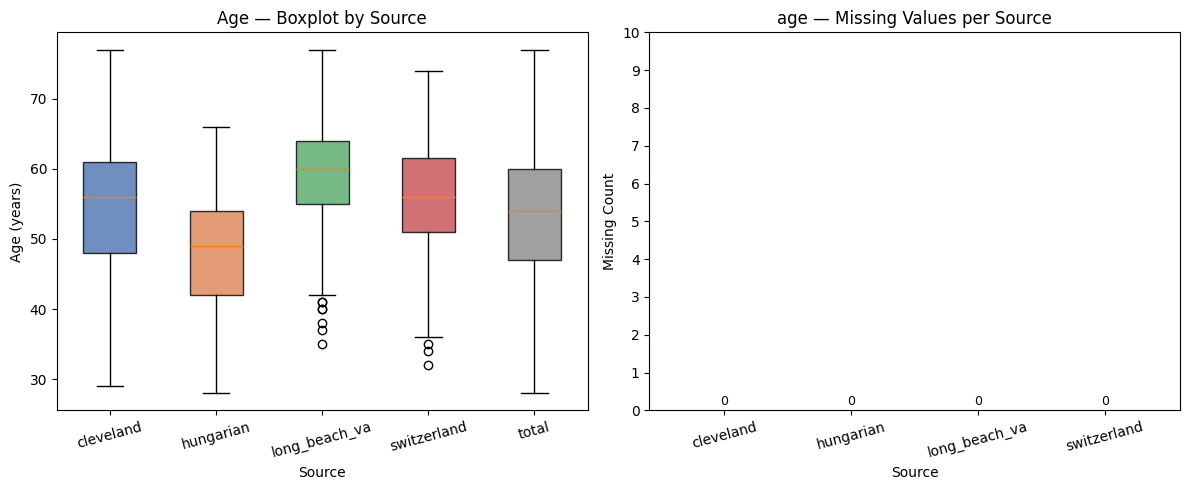

In [6]:
# --- age: boxplot per source + total ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_sources = SOURCES + ["total"]
data_by_source = [df.loc[df["source"] == s, "age"].dropna().values for s in SOURCES]
data_by_source.append(df["age"].dropna().values)

bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)
colors = [SOURCE_COLORS[s] for s in SOURCES] + ["#888888"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
axes[0].set_title("Age — Boxplot by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Age (years)")
axes[0].tick_params(axis="x", rotation=15)

plot_missing_per_source(axes[1], "age")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig("../results/figures/eda_age_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


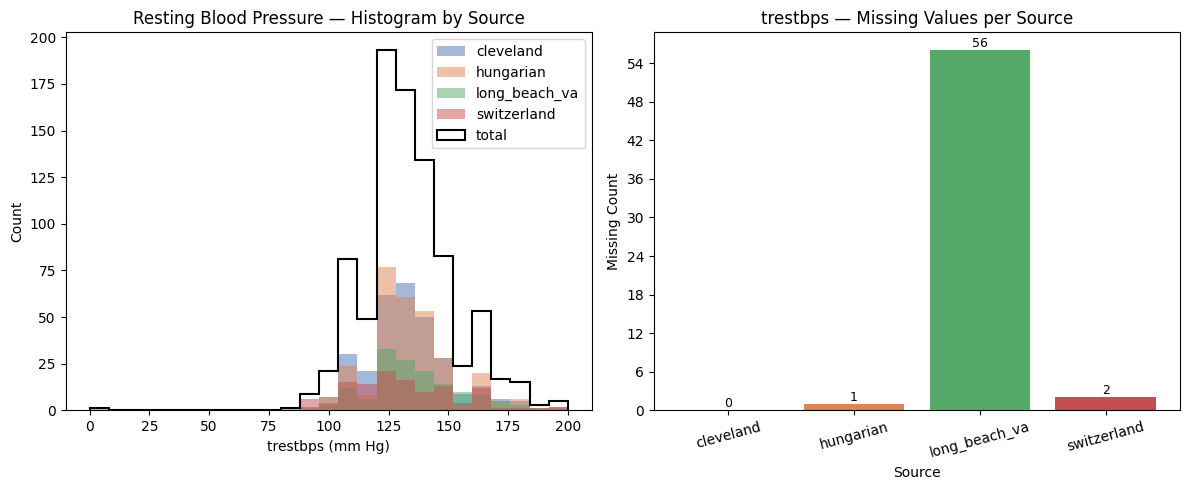

In [7]:
# --- trestbps: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["trestbps"].dropna().min(), df["trestbps"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "trestbps"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["trestbps"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Resting Blood Pressure — Histogram by Source")
axes[0].set_xlabel("trestbps (mm Hg)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "trestbps")

plt.tight_layout()
plt.savefig("../results/figures/eda_trestbps_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


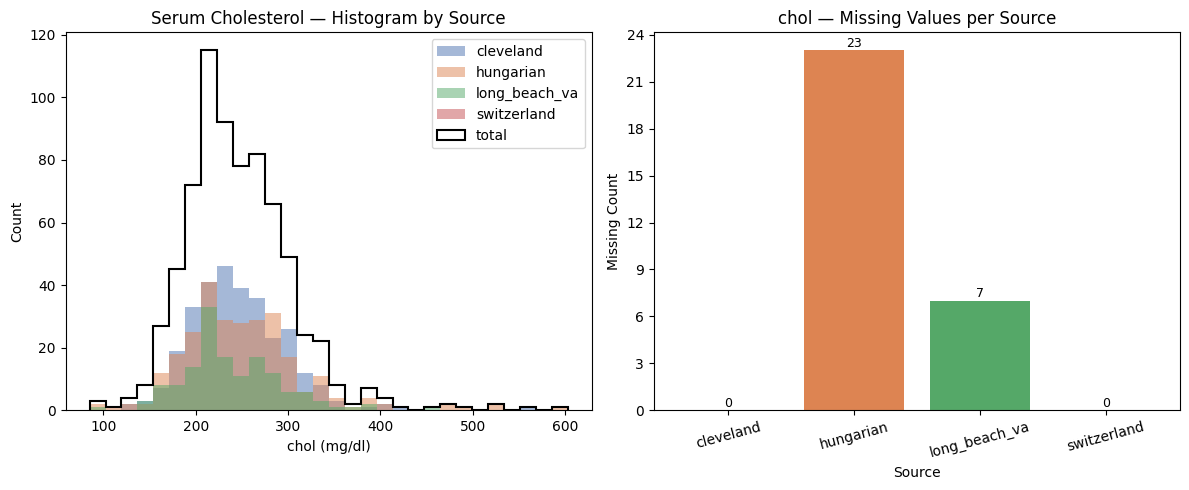

In [8]:
# --- chol: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

chol_valid = df.loc[df["chol"] > 0, "chol"].dropna()
bins = np.linspace(chol_valid.min(), chol_valid.max(), 31)
for s in SOURCES:
    vals = df.loc[(df["source"] == s) & (df["chol"] > 0), "chol"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(chol_valid, bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Serum Cholesterol — Histogram by Source")
axes[0].set_xlabel("chol (mg/dl)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "chol")

plt.tight_layout()
plt.savefig("../results/figures/eda_chol_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


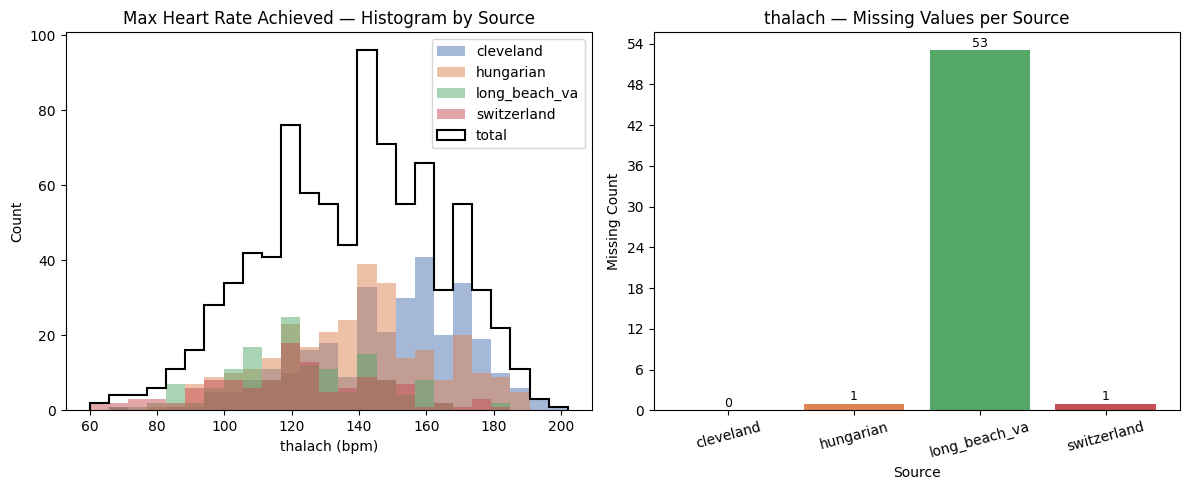

In [9]:
# --- thalach: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["thalach"].dropna().min(), df["thalach"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "thalach"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["thalach"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("Max Heart Rate Achieved — Histogram by Source")
axes[0].set_xlabel("thalach (bpm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "thalach")

plt.tight_layout()
plt.savefig("../results/figures/eda_thalach_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


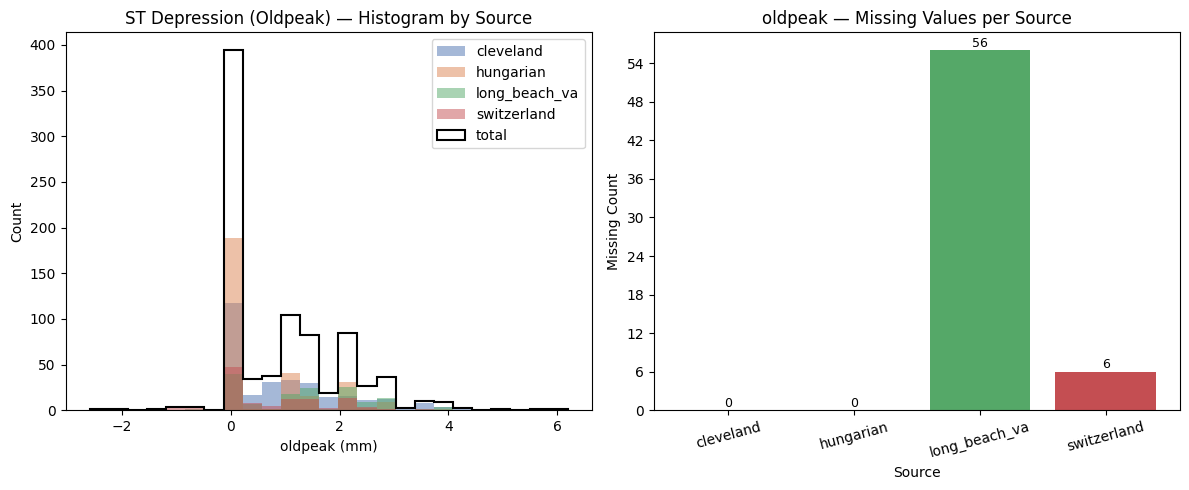

In [10]:
# --- oldpeak: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["oldpeak"].dropna().min(), df["oldpeak"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "oldpeak"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["oldpeak"].dropna(), bins=bins, histtype="step",
             color="black", linewidth=1.5, label="total")
axes[0].set_title("ST Depression (Oldpeak) — Histogram by Source")
axes[0].set_xlabel("oldpeak (mm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "oldpeak")

plt.tight_layout()
plt.savefig("../results/figures/eda_oldpeak_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


## Scatter Plots — Continuous Variable Pairs

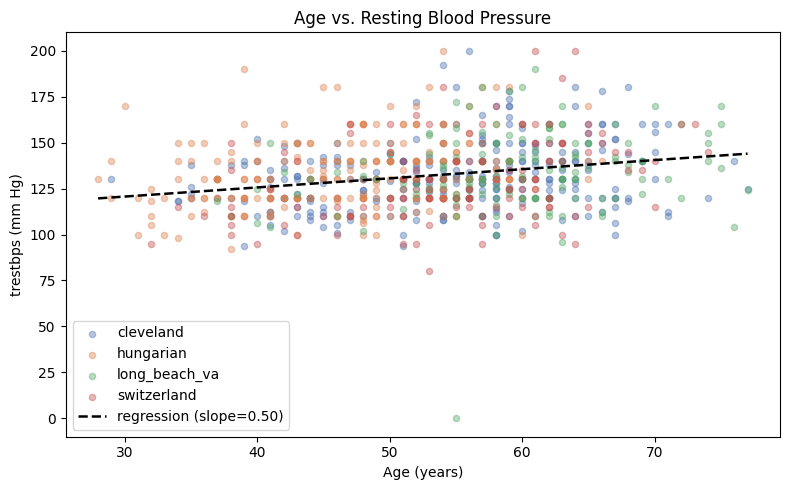

In [11]:
# --- Scatter: age vs. trestbps ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "trestbps"]].dropna()
    ax.scatter(sub["age"], sub["trestbps"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "trestbps"]].dropna()
m, b = np.polyfit(xy["age"], xy["trestbps"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Resting Blood Pressure")
ax.set_xlabel("Age (years)")
ax.set_ylabel("trestbps (mm Hg)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_scatter_age_trestbps.png", dpi=150, bbox_inches="tight")
plt.show()


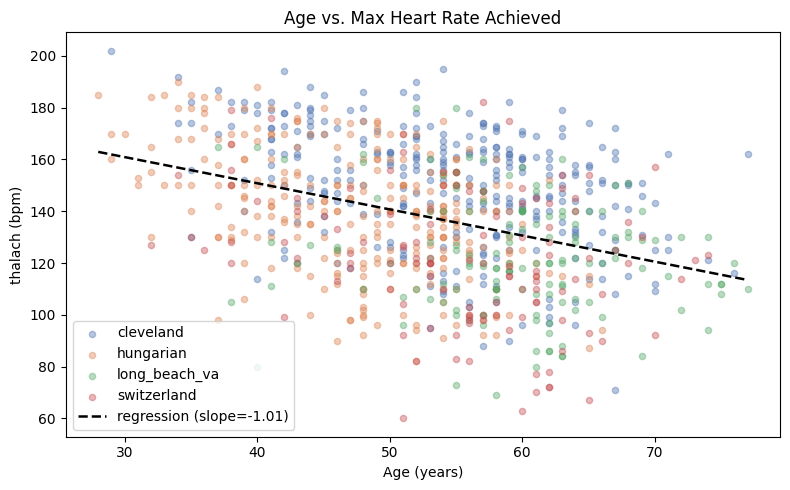

In [12]:
# --- Scatter: age vs. thalach ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "thalach"]].dropna()
    ax.scatter(sub["age"], sub["thalach"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "thalach"]].dropna()
m, b = np.polyfit(xy["age"], xy["thalach"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Max Heart Rate Achieved")
ax.set_xlabel("Age (years)")
ax.set_ylabel("thalach (bpm)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_scatter_age_thalach.png", dpi=150, bbox_inches="tight")
plt.show()


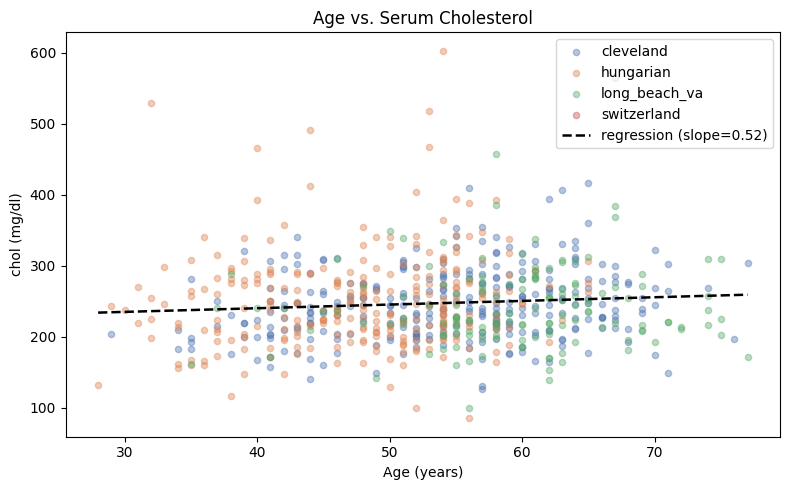

In [13]:
# --- Scatter: age vs. chol ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["age", "chol"]].dropna()
    ax.scatter(sub["age"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["age", "chol"]].dropna()
m, b = np.polyfit(xy["age"], xy["chol"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Serum Cholesterol")
ax.set_xlabel("Age (years)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_scatter_age_chol.png", dpi=150, bbox_inches="tight")
plt.show()


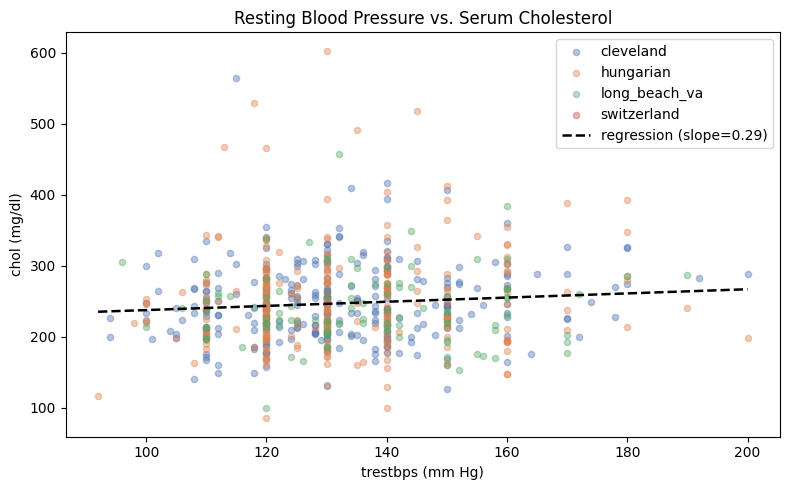

In [14]:
# --- Scatter: trestbps vs. chol ---
fig, ax = plt.subplots(figsize=(8, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["trestbps", "chol"]].dropna()
    ax.scatter(sub["trestbps"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["trestbps", "chol"]].dropna()
m, b = np.polyfit(xy["trestbps"], xy["chol"], 1)
x_line = np.array([xy["trestbps"].min(), xy["trestbps"].max()])
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Resting Blood Pressure vs. Serum Cholesterol")
ax.set_xlabel("trestbps (mm Hg)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/eda_scatter_trestbps_chol.png", dpi=150, bbox_inches="tight")
plt.show()
